# Лабораторная работа №1: Первичное исследование и оценка качества данных (продолжение)
### Загрузка данных

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/retail_sales_dataset.csv')

np.random.seed(42)
missing_mask = np.random.random(len(df)) < 0.1
df.loc[missing_mask, 'Age'] = np.nan

np.random.seed(123)
outlier_indices = np.random.choice(df.index, size=5, replace=False)
df.loc[outlier_indices, 'Total Amount'] = [25000, 30000, 50000, 100000, 75000]

### Исследование данных

In [4]:
print("Первые 5 строк данных:")
print(df.head())
print("Информация о данных:")
print(df.info())
print("Уникальные значения для столбцов:")
for column in df.columns:
    print(f"\n{column}:")
    print(f"Примеры значений: {df[column].unique()}")
    print(f"Количество уникальных значений: {df[column].nunique()}")

Первые 5 строк данных:
   Transaction ID        Date Customer ID  Gender   Age Product Category  \
0               1  2023-11-24     CUST001    Male  34.0           Beauty   
1               2  2023-02-27     CUST002  Female  26.0         Clothing   
2               3  2023-01-13     CUST003    Male  50.0      Electronics   
3               4  2023-05-21     CUST004    Male  37.0         Clothing   
4               5  2023-05-06     CUST005    Male  30.0           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    1000 non-null   int64  


## 1. Типы признаков и шкалы измерения
### Задание 1
### 1.1 Тип шкалы
#### Номинальная
1. Transaction ID - идентификатор - нет порядка
2. Customer ID - идентификатор - нет порядка
3. Gender - Male/Female - нет естественного порядка
#### Интервальная
1. Date - есть порядок и равные интервалы, но нет естественного нуля (умножение и деление некорректно)
#### Шкала отношений / абсолютная
1. Age - есть абсолютный ноль, допустимо кратное сравнение
2. Quantity - есть абсолютный ноль, допустимо кратное сравнение
3. Price per Unit - есть абсолютный ноль, допустимо кратное сравнение
4. Total Amount - есть абсолютный ноль, допустимо кратное сравнение
### 1.2 Ответы на вопросы
#### Age — шкала отношений
1. Имеет смысл вычислять среднее
2. Имеет смысл вычислять медиану, как меру центральной тенденции для количественных данных
3. Имеет смысл вычислять моду
#### Product Category (номинальная)
1. Не имеет смысла вычислять среднее, так как категории не имеют числового значения
2. Не имеет смысла вычислять медиану, так как медиана требует упорядоченности, а у номинальных категорий нет естественного порядка
3. Имеет смысл вычислять моду
#### Age — шкала отношений
| Агрегат  | Математически | Методологически   | Обоснование                                                        |
|----------|---------------|-------------------|--------------------------------------------------------------------|
| Среднее  | корректно     | корректно         | Имеет смысл "средний возраст" покупателей                          |
| Медиана  | корректно     | корректно         | "Центральный возраст" информативен                                 |
| Мода     | корректно     | корректно         | "Самый частый возраст" показывает ядро целевой аудитории           |
| Сумма    | корректно     | нет               | "Общий возраст всех клиентов" можно вычислить, но не имеет практической ценности |
| Стандартное отклонение | корректно     | корректно         | Характеризует разброс возраста вокруг среднего                     |
| Дисперсия | корректно     | корректно         | Квадрат отклонений имеет смысл для анализа распределения           |
| Минимум  | корректно     | корректно         | Показывает возраст самого молодого покупателя                      |
| Максимум | корректно     | корректно         | Показывает возраст самого пожилого покупателя                      |
| Процентили | корректно     | корректно         | Доли распределения значимы, показывают положение в выборке         |
| Коэффициент вариации | корректно     | корректно         | Относительный разброс, позволяет сравнивать разные группы          |
| Размах   | корректно     | корректно         | Диапазон значеий                                                   |
| Межквартильный размах | корректно     | корректно         | Разброс центральной части данных                                   |
####
#### Product Category — номинальная шкала
| Агрегат  | Математически | Методологически   | Обоснование                                                                         |
|----------|---------------|-------------------|-------------------------------------------------------------------------------------|
| Среднее  | нет     | нет         | Бессмысленно для номинальных данных                                                 |
| Медиана  | нет     | нет         | Требует естественного порядка, которого нет                                         |
| Мода     | корректно     | корректно         | Имеет смысл найти "самую частую категорию"                                          |
| Сумма    | нет     | нет               | Не имеет смысла                                                                     |
| Стандартное отклонение | нет     | нет         | Бессмысленно для номинальных данных                                                 |
| Дисперсия | нет     | нет         | Бессмысленно для номинальных данных                                                 |
| Минимум  | нет     | нет         | Бессмысленно для номинальных данных                                                 |
| Максимум | нет     | нет         | Бессмысленно для номинальных данных                                                 |
| Процентили | нет     | нет         | Требуют осмысленного упорядочения, которого нет                                     |
| Коэффициент вариации | нет     | нет         | Основан на среднем и стандартном отклонении, оба бессмысленны для номинальной шкалы |
| Размах   | нет     | нет         | Бессмысленно для номинальных данных                                                 |
| Межквартильный размах | нет     | нет         | Бессмысленно для номинальных данных                                                 |
##
## 2 Пропуски и их природа (MCAR / MAR / MNAR)
### Задание 2. Диагностика типа пропусков
#### 2.1 Три альтернативные гипотезы
1. MCAR: пропуски в Age возникают полностью случайно и не зависят ни от каких других переменных в датасете, ни от самого значения возраста
2. MAR: вероятность пропуска в Age зависит от других наблюдаемых переменных, но не зависит от самого значения Age после учёта этих переменных
3. MNAR: вероятность пропуска в Age зависит от самого значения этого признака
#### 2.2 Проверка гипотез
##### Какие признаки помогут проверить:
1. Все оставшиеся признаки. Если MCAR верна, то распределения признаков в группе с пропуском Age и без пропуска не должны различаться
2. Те же самые признаки. Если MAR верна, то пропуски связаны с другими наблюдаемыми переменными
3. Прямых наблюдаемых признаков нет, потому что сам Age пропущен. Нужны косвенные методы и внешние данные

### Проверка для MCAR

In [5]:
from scipy.stats import chi2_contingency
df['Age_missing'] = df['Age'].isna()
# Категориальные признаки
cat_cols = ['Gender', 'Product Category']
for col in cat_cols:
    cont_table = pd.crosstab(df[col], df['Age_missing'])
    chi2, p, dof, expected = chi2_contingency(cont_table)
    print(f"{col:20} | Chi2 = {chi2:.3f} | p-value = {p:.4f} | {'Нет различий (MCAR)' if p > 0.05 else 'Есть различия (не MCAR)'}")

Gender               | Chi2 = 0.014 | p-value = 0.9059 | Нет различий (MCAR)
Product Category     | Chi2 = 1.860 | p-value = 0.3945 | Нет различий (MCAR)


### Проверка для MAR

In [6]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
# Категориальные признаки
for col in ['Gender', 'Product Category']:
    cont_table = pd.crosstab(df[col], df['Age_missing'])
    cramers = cramers_v(cont_table.values)
    print(f"{col}: Cramér's V = {cramers:.4f} (0=нет связи, 1=полная связь)")

Gender: Cramér's V = 0.0000 (0=нет связи, 1=полная связь)
Product Category: Cramér's V = 0.0000 (0=нет связи, 1=полная связь)


### Проверка для MNAR

In [7]:
# Сравниваем наблюдаемый возраст с ожидаемым
observed_ages = df[~df['Age_missing']]['Age']
print(f"\nСредний возраст (наблюдаемый): {observed_ages.mean():.1f}")
# берём все исходные возраста до удаления
print(f"Средний возраст (исходный): {df['Age'].mean():.1f}")
# Если среднее сильно отличается (более чем на 5-10%) → возможно MNAR
difference = abs(observed_ages.mean() - df['Age'].mean())
relative_diff = difference / df['Age'].mean() * 100
print(f"\nРазница средних: {difference:.1f} лет ({relative_diff:.1f}%)")

if relative_diff > 5:
    print("СРЕДНЕЕ СИЛЬНО ИЗМЕНИЛОСЬ → возможно MNAR")
else:
    print("Среднее изменилось незначительно → MCAR или MAR")


Средний возраст (наблюдаемый): 41.1
Средний возраст (исходный): 41.1

Разница средних: 0.0 лет (0.0%)
Среднее изменилось незначительно → MCAR или MAR


### Задание 3. Индикатор пропуска как источник информации
#### Объясните, в каком случае сам факт пропуска несёт информацию
Сам факт пропуска несёт информацию, когда данные пропущены не случайно:
MAR — пропуски объясняются другими наблюдаемыми переменными
MNAR — пропуски связаны с самим пропущенным значением
#### Почему значимость индикатора в модели - это сигнал о неправильной или грубой импутации?
Если индикатор пропуска оказался значимым в модели, значит, пропущенные и заполненные значения систематически различаются, а импутация этого не учла
##### Почему это плохо:
| Ситуация                   | Что означает значимый индикатор                            | Проблема                              |
|----------------------------|------------------------------------------------------------|---------------------------------------|
| Импутация средним/медианой | Пропущенные значения систематически отличаются от среднего | Импутация исказила распределение      |
| Импутация модой            | Пропущенные значения не типичны                            | Импутация создала ложную однородность |
| Импутация регрессией       | Модель импутации недоучла важные связи                     | Нужно улучшить модель импутации       |
| Прямое удаление пропусков  | Пропуски не случайны                                       | Удаление внесло смещение              |
#### Приведите пример признака, для которого индикатор пропуска:
1. Полезен:
Product Category. Можно предположить, что это пропуск MAR (может зависеть от Age/Gender). Пропуск может указывать на демографию клиента
2. Бесполезен:
Age. MCAR - пропуски случайны, без связи с другими признаками
3. Опасен:
Price per Unit. Можно предположить, что это пропуск MNAR (зависит от самой цены). Создаёт ложные корреляции
## 3 Выбросы
### Задание 4. Выброс - это ошибка или сигнал?

Статистика Total Amount:
count      1000.000000
mean        733.650000
std        4432.671571
min          25.000000
25%          60.000000
50%         150.000000
75%         900.000000
max      100000.000000
Name: Total Amount, dtype: float64


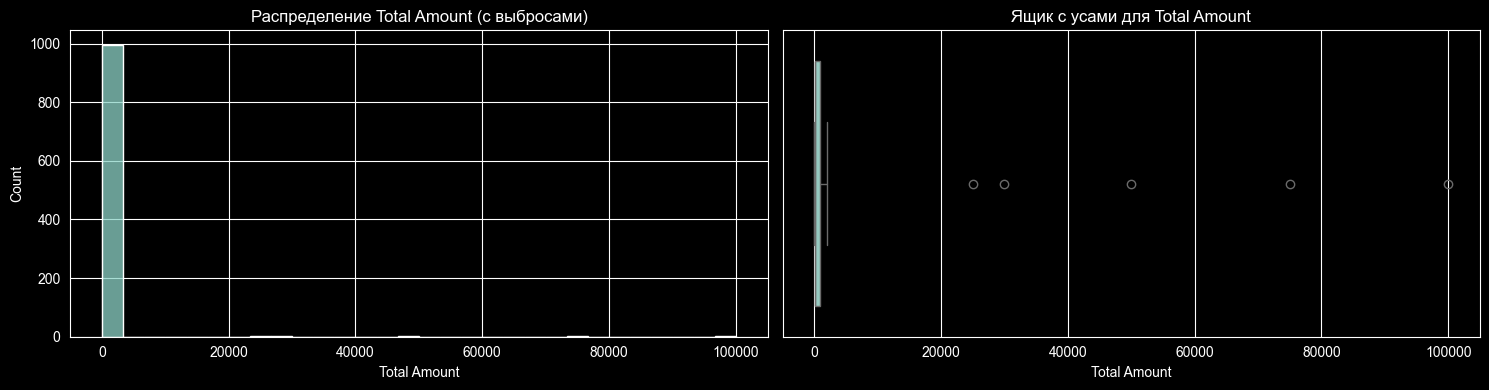


Границы для выбросов (IQR метод):
Нижняя граница: -1200.00
Верхняя граница: 2160.00
Количество выбросов: 5
Процент выбросов: 0.50%

Топ-5 максимальных значений Total Amount:
585    100000
138     75000
50      50000
203     30000
131     25000
Name: Total Amount, dtype: int64

Топ-5 минимальных значений Total Amount:
43     25
102    25
184    25
190    25
200    25
Name: Total Amount, dtype: int64


In [8]:
print("Статистика Total Amount:")
print(df['Total Amount'].describe())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(df['Total Amount'], bins=30, ax=axes[0])
axes[0].set_title('Распределение Total Amount (с выбросами)')
axes[0].set_xlabel('Total Amount')

sns.boxplot(x=df['Total Amount'], ax=axes[1])
axes[1].set_title('Ящик с усами для Total Amount')

plt.tight_layout()
plt.show()

# --- ОПРЕДЕЛЕНИЕ ВЫБРОСОВ (метод IQR) ---
Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Total Amount'] < lower_bound) | (df['Total Amount'] > upper_bound)]

print(f"\nГраницы для выбросов (IQR метод):")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(df)*100:.2f}%")

print("\nТоп-5 максимальных значений Total Amount:")
print(df['Total Amount'].nlargest(5))

print("\nТоп-5 минимальных значений Total Amount:")
print(df['Total Amount'].nsmallest(5))

#### Какие реальные причины могут объяснить значение 100000?
1. Ошибка ввода данных
2. Корпоративная/оптовая закупка
3. Тестовая транзакция
#### Что хуже для анализа: удалить, оставить, преобразовать?
Оставить без изменений, так как:
1. Линейные модели смещаются в сторону выброса, искажая все предсказания
2. Метрики становятся огромными из-за одного наблюдения
3. Визуализации становятся нечитаемыми
## 4 Статистики
### Задание 5. Преобразование или винзоризация?
#### В каких случаях предпочтительнее?
1. Логарифмирование:
- Сильная правосторонняя асимметрия
- Экспоненциальный рост значений
- Все значения > 0
- Относительные изменения важны
2. Квадратный корень:
- Умеренная асимметрия
- Счётные данные (целые числа)
- Есть нули
- Нужно сохранить единицы измерения
3. Винзоризация:
- Отдельные экстремальные выбросы
- Хотим сохранить исходную шкалу
- Выбросы — вероятные ошибки
- Важна интерпретация в исходных единицах

Среднее: 733.65
Медиана: 150.00
Максимум: 100000.00
Асимметрия: 17.81


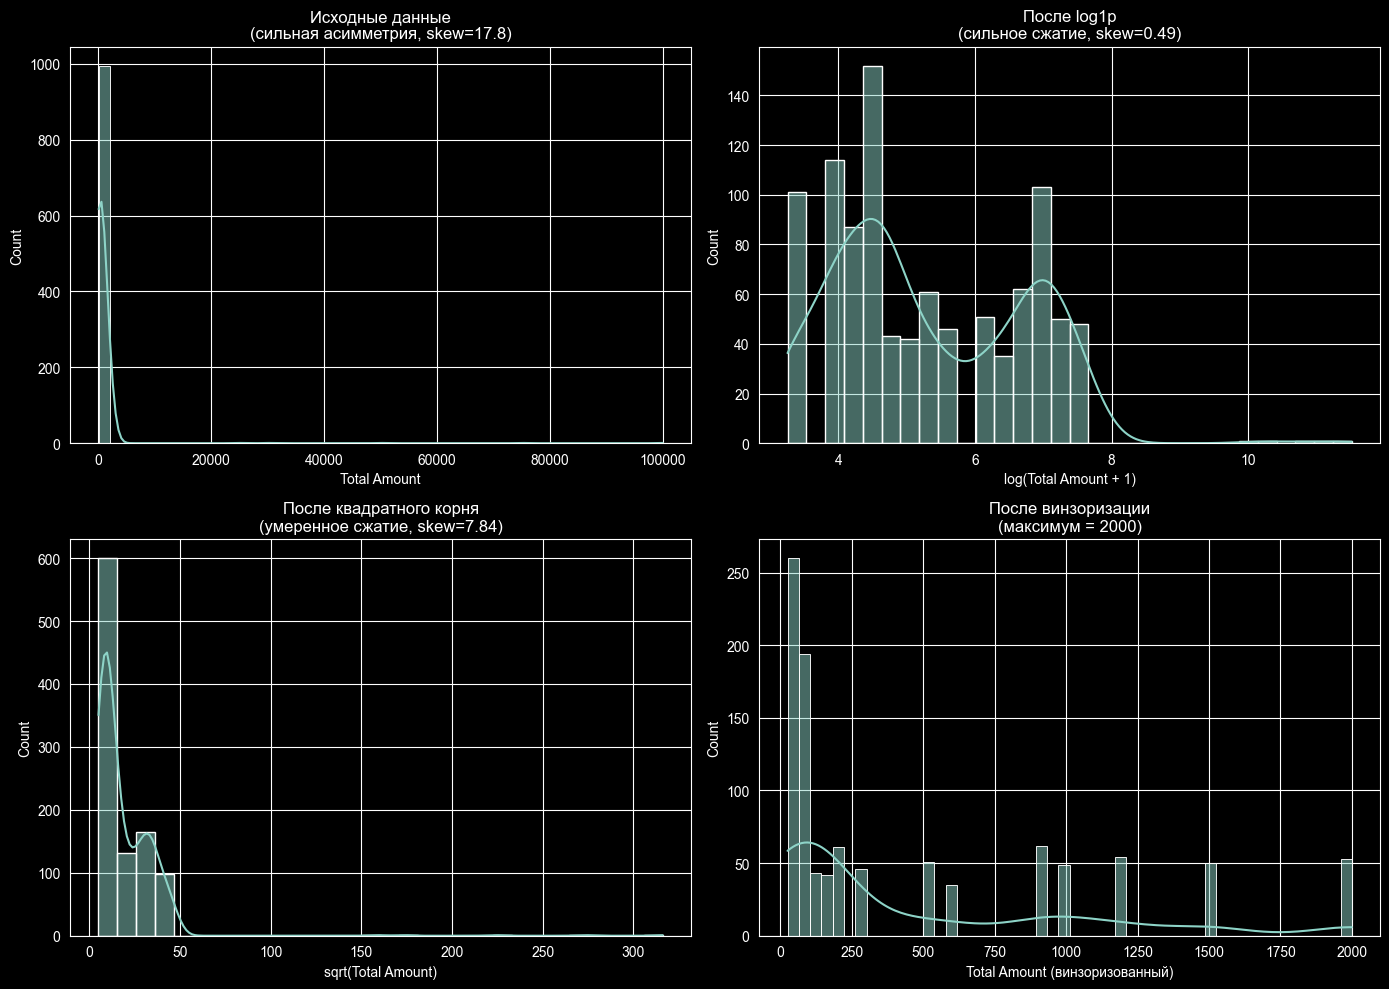

In [11]:
column = 'Total Amount'

# Исходное распределение
print(f"Среднее: {df[column].mean():.2f}")
print(f"Медиана: {df[column].median():.2f}")
print(f"Максимум: {df[column].max():.2f}")
print(f"Асимметрия: {df[column].skew():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Исходные данные
sns.histplot(df[column], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title(f'Исходные данные\n(сильная асимметрия, skew={df[column].skew():.1f})')
axes[0,0].set_xlabel('Total Amount')
axes[0,0].set_xlim(-5000, 105000)

# 2. После логарифмирования
df['log_total'] = np.log1p(df[column])  # log(1 + x)
sns.histplot(df['log_total'], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title(f'После log1p\n(сильное сжатие, skew={df["log_total"].skew():.2f})')
axes[0,1].set_xlabel('log(Total Amount + 1)')

# 3. После квадратного корня
df['sqrt_total'] = np.sqrt(df[column])
sns.histplot(df['sqrt_total'], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title(f'После квадратного корня\n(умеренное сжатие, skew={df["sqrt_total"].skew():.2f})')
axes[1,0].set_xlabel('sqrt(Total Amount)')

# 4. После винзоризации (обрезаем 99-й процентиль)
upper = df[column].quantile(0.99)
df_winsor = df[column].clip(upper=upper)
sns.histplot(df_winsor, bins=50, kde=True, ax=axes[1,1])
axes[1,1].set_title(f'После винзоризации\n(максимум = {int(upper)})')
axes[1,1].set_xlabel('Total Amount (винзоризованный)')

plt.tight_layout()
plt.show()

#### Влияние на интерпретируемость, модели и визуализацию
1. Интерпретируемость
- Логарифмирование: Сильно страдает («Изменение на 0.1 в логарифме» не понятно)
- Квадратный корень: Сильно страдает (Квадратный корень из суммы — неестественно)
- Винзоризация: Низкое влияние (Единицы измерения те же - рубли)
2. Линейные модели
- Логарифмирование: Сильно помогает (Сжатие выбросов, распределение ближе к нормальному)
- Квадратный корень: Помогает (Умеренное сжатие, но выбросы всё ещё видны)
- Винзоризация: Помогает (Убирает экстремальные выбросы, сохраняя порядок значений)
3. Визуализация
- Логарифмирование: Сильно улучшает
- Квадратный корень: Улучшает
- Винзоризация: Средне (Хвост обрезан, но распределение всё ещё асимметрично)
### Задание 6. Средние, которые вводят в заблуждение

In [13]:
from scipy.stats import gmean
arithmetic_mean = df['Total Amount'].mean()
median = df['Total Amount'].median()
geometric_mean = gmean(df['Total Amount'] + 1) - 1  # +1 чтобы избежать нулей
print(f"Арифметическое среднее:   {arithmetic_mean:,.2f} руб.")
print(f"Медиана:                  {median:,.2f} руб.")
print(f"Геометрическое среднее:   {geometric_mean:,.2f} руб.")

Арифметическое среднее:   733.65 руб.
Медиана:                  150.00 руб.
Геометрическое среднее:   203.76 руб.


##### Значения разнятся
##### Разнятся, так как:
- 95% данных лежат в диапазоне 25–2000 руб
- 5 выбросов (25000, 30000, 50000, 75000, 100000) «тянут» арифметическое вверх с 150.00 руб. до 733.65 руб.
- Медиана остаётся на своём месте (150 руб.), так как выбросы находятся в хвосте распределения
##### Лучше отражает «типичное» значение медиана, потому что высокая устойчивость к выбросам, отражает большинство данных (Типичный чек обычного клиента)

## 5 Визуализация как инструмент мышления
### Задание 7. Неправильная диаграмма

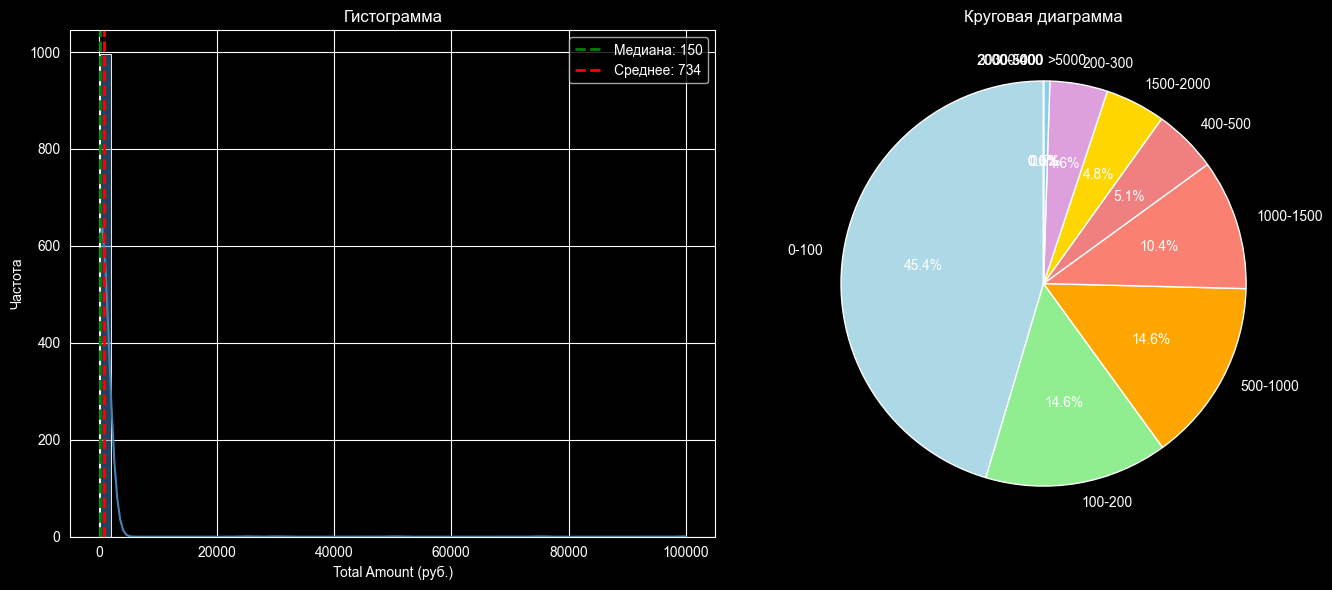

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Total Amount'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Гистограмма', fontsize=12)
axes[0].set_xlabel('Total Amount (руб.)')
axes[0].set_ylabel('Частота')
axes[0].axvline(df['Total Amount'].median(), color='green', linestyle='--',
                linewidth=2, label=f'Медиана: {df["Total Amount"].median():.0f}')
axes[0].axvline(df['Total Amount'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Среднее: {df["Total Amount"].mean():.0f}')
axes[0].legend()


df['Amount_Category'] = pd.cut(df['Total Amount'],
                                bins=[0, 100, 200, 300, 400, 500, 1000, 1500, 2000, 3000, 5000, 100000],
                                labels=['0-100', '100-200', '200-300', '300-400', '400-500',
                                        '500-1000', '1000-1500', '1500-2000', '2000-3000',
                                        '3000-5000', '>5000'])
category_counts = df['Amount_Category'].value_counts()
n_categories = len(category_counts)
colors_list = ['lightblue', 'lightgreen', 'orange', 'salmon',
               'lightcoral', 'gold', 'plum', 'skyblue',
               'lightgray', 'khaki', 'violet', 'tomato'][:n_categories]

axes[1].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors_list)
axes[1].set_title('Круговая диаграмма', fontsize=12)

plt.tight_layout()
plt.show()

#### Докозательство:
Круговая диаграмма категорически не подходит для отображения распределения непрерывного числового признака Total Amount, так как:
1. Предназначена для категориальных данных
2. Плохо работает с большим числом значений
3. Не позволяет увидеть выбросы
#### Какую информацию круговая диаграмма исказила бы:
1. Выбросы и их влияние
2. Реальная форма распределения
3. Разница между средним и медианой
#### Какой неверный вывод мог бы сделать зритель:
Выбросы (>5000) — это редкое исключение, которым можно пренебречь (эти 0.5% транзакций могут составлять 50-80% всей выручки)
### Задание 8. Одна и та же информация - разные графики

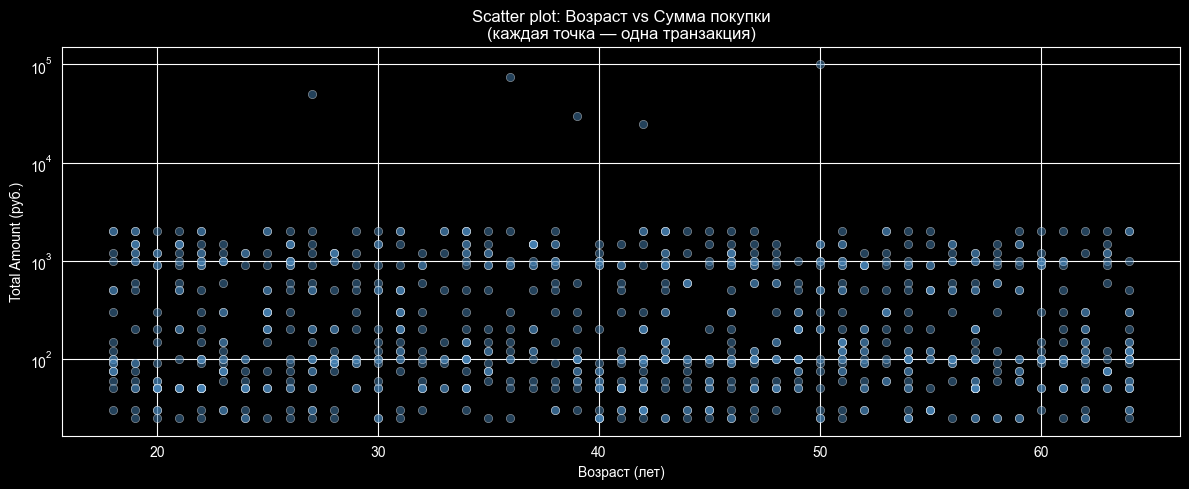

In [21]:
# Scatter plot
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x='Age', y='Total Amount', alpha=0.5, color='steelblue')
plt.title('Scatter plot: Возраст vs Сумма покупки\n(каждая точка — одна транзакция)', fontsize=12)
plt.xlabel('Возраст (лет)', fontsize=10)
plt.ylabel('Total Amount (руб.)', fontsize=10)
plt.yscale('log')  # логарифмическая шкала для выбросов
plt.tight_layout()
plt.show()

#### Какую информацию подчёркивает график
1. Хорошо видна форма связи (линейная, нелинейная)
2. Пропуски в данных - видны как пустые области
3. Индивидуальные наблюдения - каждая точка видна
4. Выбросы - каждый выброс виден как изолированная точка
5. Границы значений — минимальные и максимальные значения по обеим осям

C:\Users\Артур\AppData\Local\Temp\ipykernel_18388\2560486217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Age_Group', y='Total Amount', palette='Set2')


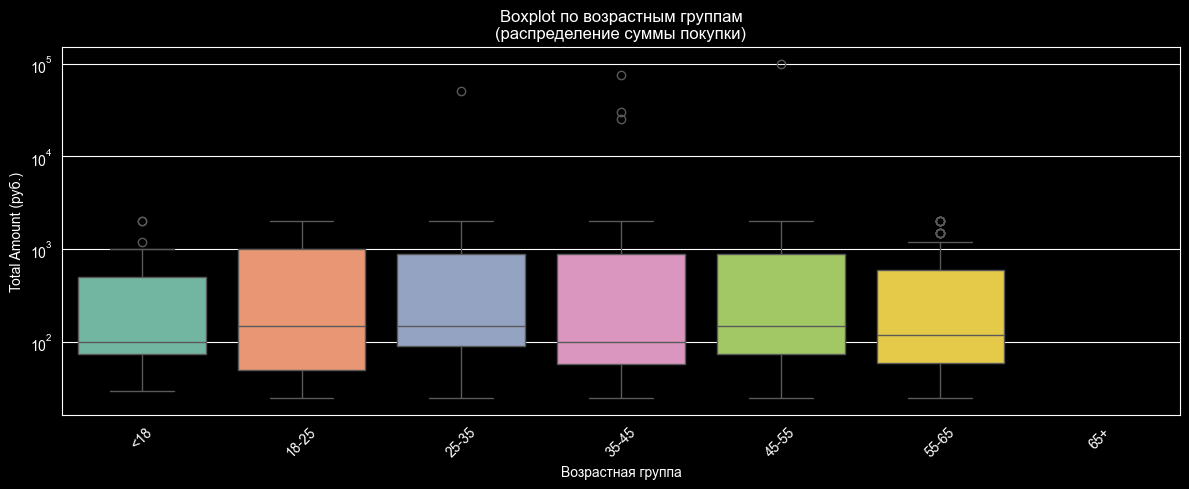

In [22]:
#Boxplot по возрастным группам
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 18, 25, 35, 45, 55, 65, 100],
                          labels=['<18', '18-25', '25-35', '35-45', '45-55', '55-65', '65+'])
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Age_Group', y='Total Amount', palette='Set2')
plt.title('Boxplot по возрастным группам\n(распределение суммы покупки)', fontsize=12)
plt.xlabel('Возрастная группа', fontsize=10)
plt.ylabel('Total Amount (руб.)', fontsize=10)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Какую информацию подчёркивает график
1. Медианные значения
2. Сравнение групп — удобно сравнивать медианы и разброс
3. Разброс внутри группы — высота ящика (IQR)
4. Выбросы в каждой группе — точки за усами
#### Гипотезы, которые легче заметить на диаграмме рассеяния:
1. Возраст и сумма покупки статистически независимы
#### Гипотезы, которые легче заметить на ящиках с усами:
1. Существуют крупные транзакции, не связанные с возрастом